# TURBO LP 长期未回归案例：资金去向（Notebook 3）

## 这一本只回答什么？

事件账本中只有 **1 个** campaign 同时满足：观察满30天、在已扫描 TURBO/WETH V3 池中没有 Mint 回归、30天净恢复率为0。

这本 Notebook 对它做**案例取证**：从 Burn、Collect、真实到账，一直追到钱包后续转账。它不把一个案例写成“大户通常如何操作”，也不推断地址背后的自然人。

需要特别区分：

- **Burn**：停止做市并把本金记成“可领取”；
- **Collect**：真正把本金和累计手续费转到收款地址；
- **进入公开标记的交易所地址**：只能证明链上资金到达该服务地址，不能证明账户已入账、卖成法币或最终受益人是谁。


In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

DATA = Path('data/turbo_lp_capital_destination_v1')
if not DATA.exists():
    DATA = Path('notebooks/data/turbo_lp_capital_destination_v1')

manifest = json.loads((DATA / 'manifest.json').read_text())
case = pd.read_parquet(DATA / 'persistent_case_v1.parquet')
collect = pd.read_parquet(DATA / 'burn_collect_fact_v1.parquet')
transfers = pd.read_parquet(DATA / 'wallet_token_transfers_v1.parquet')
withdrawals = pd.read_parquet(DATA / 'weth_withdrawals_v1.parquet')
wallet_txs = pd.read_parquet(DATA / 'wallet_transactions_v1.parquet')
intermediary_txs = pd.read_parquet(DATA / 'intermediary_transactions_v1.parquet')
native = pd.read_parquet(DATA / 'native_outflows_v1.parquet')
balances = pd.read_parquet(DATA / 'wallet_balance_checkpoints_v1.parquet')
disposition = pd.read_parquet(DATA / 'asset_disposition_v1.parquet')
edges = pd.read_parquet(DATA / 'fund_flow_edges_v1.parquet')
labels = pd.read_csv(DATA / 'address_labels_v1.csv')
censored = pd.read_csv(DATA / 'censored_appendix_v1.csv')

display(pd.Series({
    'campaign': manifest['campaign_id'],
    'Burn 区块': manifest['burn_block_number'],
    '30天追踪终点区块': manifest['analysis_end_block_30d'],
    '原钱包': manifest['wallet_address'],
    '合格长期未回归样本数': 1,
    '附录截断样本数': len(censored),
}).to_frame('value'))


,value
campaign,lp-campaign-00001
Burn 区块,25395400
30天追踪终点区块,25610542
原钱包,0x34756D8400f2426851dc46D6ab38F0Df004CE1E7
合格长期未回归样本数,1
附录截断样本数,1


## Part 1：先确认 Burn 和 Collect 不是一回事

这笔交易在同一交易中依次发生了 Burn、DecreaseLiquidity、Collect 和两笔真实 ERC-20 Transfer。下面使用 Position Manager 的 `tokenId=1257405` 精确匹配，不是用相近金额猜测。


In [2]:
r = collect.iloc[0]
display(pd.DataFrame([
    {'项目': 'Burn/DecreaseLiquidity 本金', 'TURBO': r.burn_turbo_principal, 'WETH': r.burn_weth_principal},
    {'项目': 'Collect 实际到账', 'TURBO': r.collected_turbo, 'WETH': r.collected_weth},
    {'项目': 'Collect 比本金多出的金额', 'TURBO': r.collect_minus_burn_turbo, 'WETH': r.collect_minus_burn_weth},
]).style.format({'TURBO': '{:,.6f}', 'WETH': '{:,.9f}'}))

display(Markdown(
    f"**白话解释：** LP 撤出的本金约为 {r.burn_turbo_principal:,.2f} TURBO + "
    f"{r.burn_weth_principal:.6f} WETH；真正 Collect 到钱包的是 "
    f"{r.collected_turbo:,.2f} TURBO + {r.collected_weth:.6f} WETH。"
    "多出来的部分与此前未领取金额/手续费一起到账相符，但这张表不把差额进一步拆成具体手续费来源。"
))


,项目,TURBO,WETH
0,Burn/DecreaseLiquidity 本金,"47,684,160.427459",2.529694611
1,Collect 实际到账,"48,189,754.558588",2.778046405
2,Collect 比本金多出的金额,"505,594.131130",0.248351794


**白话解释：** LP 撤出的本金约为 47,684,160.43 TURBO + 2.529695 WETH；真正 Collect 到钱包的是 48,189,754.56 TURBO + 2.778046 WETH。多出来的部分与此前未领取金额/手续费一起到账相符，但这张表不把差额进一步拆成具体手续费来源。

## Part 2：钱在原钱包里停留了多久？

钱包在 Collect 之前本来就有少量 TURBO 和 WETH。ERC-20 是可以混合的，因此我们只能说“Collect 后钱包里的全部余额如何变化”，不能逐颗认定哪一枚币一定来自这次撤资。


,asset,opening_balance,collected_amount,available_after_collect,outbound_amount,closing_balance,wallet_balance_fully_disposed,outbound_over_collected_ratio,non_transfer_disposal
0,TURBO,"536,390.572039","48,189,754.558588","48,726,145.130628","48,726,145.130628",0.000000,True,101.11%,0.000000
1,WETH,0.006540,2.778046,2.784586,0.000000,0.000000,True,0.00%,2.784586


/var/folders/56/4nq1_gvn5c17bwx0djrtyj1m0000gn/T/ipykernel_41337/3279036993.py:21: UserWarning: Glyph 26816 (\N{CJK UNIFIED IDEOGRAPH-68C0}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/56/4nq1_gvn5c17bwx0djrtyj1m0000gn/T/ipykernel_41337/3279036993.py:21: UserWarning: Glyph 26597 (\N{CJK UNIFIED IDEOGRAPH-67E5}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/56/4nq1_gvn5c17bwx0djrtyj1m0000gn/T/ipykernel_41337/3279036993.py:21: UserWarning: Glyph 26102 (\N{CJK UNIFIED IDEOGRAPH-65F6}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/56/4nq1_gvn5c17bwx0djrtyj1m0000gn/T/ipykernel_41337/3279036993.py:21: UserWarning: Glyph 28857 (\N{CJK UNIFIED IDEOGRAPH-70B9}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/56/4nq1_gvn5c17bwx0djrtyj1m0000gn/T/ipykernel_41337/3279036993.py:21: UserWarning: Glyph 30456 (\N{CJK UNIFIED IDEOGRAPH-76F8}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/56/4nq1

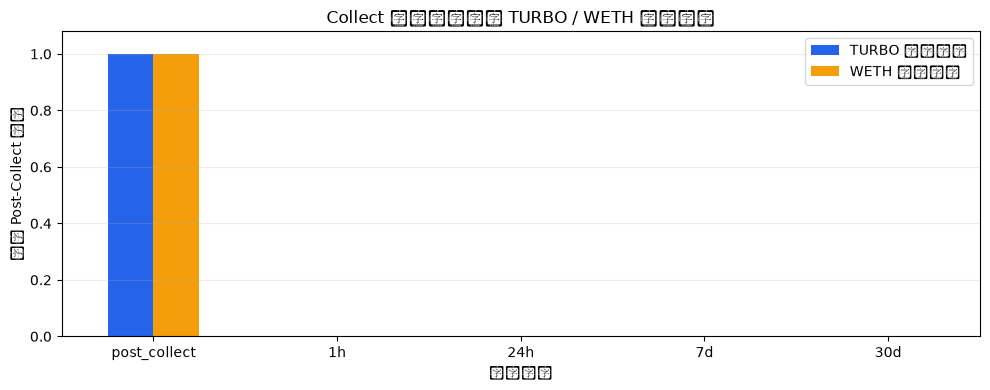

**图的意思：** 1小时检查时，原钱包的 TURBO 和 WETH 都已经为0；24小时、7天、30天仍为0。这证明资金没有留在原钱包，但单凭这张图还不能判断它去了哪里，所以必须继续读下面的交易链。

In [3]:
display(disposition.style.format({
    'opening_balance': '{:,.6f}', 'collected_amount': '{:,.6f}',
    'available_after_collect': '{:,.6f}', 'outbound_amount': '{:,.6f}',
    'closing_balance': '{:,.6f}', 'outbound_over_collected_ratio': '{:.2%}',
    'non_transfer_disposal': '{:,.6f}',
}))

plot = balances[balances.checkpoint != 'pre_burn'].copy()
post = plot.iloc[0]
plot['TURBO 留存比例'] = plot.turbo_balance / post.turbo_balance
plot['WETH 留存比例'] = plot.weth_balance / post.weth_balance
ax = plot.set_index('checkpoint')[['TURBO 留存比例', 'WETH 留存比例']].plot(
    kind='bar', figsize=(10, 4), color=['#2563eb', '#f59e0b']
)
ax.set_title('Collect 后原钱包中的 TURBO / WETH 留存比例')
ax.set_ylabel('相对 Post-Collect 余额')
ax.set_xlabel('检查时点')
ax.set_ylim(0, 1.08)
ax.tick_params(axis='x', rotation=0)
ax.grid(axis='y', alpha=.25)
plt.tight_layout()
plt.show()

display(Markdown(
    "**图的意思：** 1小时检查时，原钱包的 TURBO 和 WETH 都已经为0；24小时、7天、30天仍为0。"
    "这证明资金没有留在原钱包，但单凭这张图还不能判断它去了哪里，所以必须继续读下面的交易链。"
))


## Part 3：TURBO 和 WETH 如何离开原钱包？

- TURBO 在 Burn 后约1–5分钟内分批进入交易执行路径；
- WETH 在约2分钟后由原钱包调用 WETH 合约解包为原生 ETH；
- 两个 KyberSwap 聚合交易、一个 1inch 路由交易和一个公开标记的执行合约出现在连续交易中。

路由器只是交易中间设施，不等于最终收款人。

特别注意：WETH解包由WETH合约的`Withdrawal`事件直接确认。TURBO进入交易执行路径也有Transfer日志；但当前RPC不提供内部调用Trace，因此这里不把后续每一笔ETH强行归因到某一笔TURBO交易。


In [4]:
out = transfers[transfers.direction == 'out'].copy()
label_map = labels.set_index('address').label.to_dict()
out['去向说明'] = out.to_address.map(label_map).fillna('未标记地址')
display(out[['datetime_utc','asset','amount','to_address','去向说明','transaction_hash']].style.format({'amount':'{:,.6f}'}))

display(withdrawals[['datetime_utc','weth_unwrapped','transaction_hash']].style.format({'weth_unwrapped':'{:,.9f}'}))


,datetime_utc,asset,amount,to_address,去向说明,transaction_hash
2,2026-06-25T15:01:47+00:00,TURBO,"47,507.991502",0xcD6b980029E6E6e0733ac8eC3E02be9410D09799,Unlabeled EOA receiving 0.25% of routed TURBO,0x488db2da5e034f87a70bd753b9605b0cfa96c5ac51a9d8981cc377d7cf5a4dca
3,2026-06-25T15:01:47+00:00,TURBO,"18,955,688.609398",0x8F10B468b06c6FD214B65F87778827F7D113f996,KyberSwap transaction execution contract,0x488db2da5e034f87a70bd753b9605b0cfa96c5ac51a9d8981cc377d7cf5a4dca
4,2026-06-25T15:03:59+00:00,TURBO,"49,042.865074",0xcD6b980029E6E6e0733ac8eC3E02be9410D09799,Unlabeled EOA receiving 0.25% of routed TURBO,0x226cac14c9b0c37634985cc477379d8d6932034e2ec370b26b882ef9ab83edbd
5,2026-06-25T15:03:59+00:00,TURBO,"19,568,103.164526",0x8F10B468b06c6FD214B65F87778827F7D113f996,KyberSwap transaction execution contract,0x226cac14c9b0c37634985cc477379d8d6932034e2ec370b26b882ef9ab83edbd
6,2026-06-25T15:05:23+00:00,TURBO,"10,105,802.500128",0xEff6cb8b614999d130E537751Ee99724D01aA167,Publicly labeled MEV execution contract,0x8754085db2bfa76c66dcfaa861046c7f196caa575d8da4266f298d52c0cc4388


,datetime_utc,weth_unwrapped,transaction_hash
0,2026-06-25T15:02:47+00:00,2.784586396,0xe9e1e6026c1fe62014d49a3c5117c32aadaeba4c9b39e9a1b8e30c8809f88b38


## Part 4：先把23.4116 ETH的来源对上账

Collect所在区块结束时，原钱包只有约0.0743 ETH；WETH解包只增加约2.7846 ETH，但钱包随后转出了23.4116 ETH。因此，不能把23.4116 ETH全部说成“撤出的WETH”。

下面用钱包余额恒等式反推同期其他原生ETH流入。这个残差与相邻交易路由在时间上吻合，但这里只把它当作可核验的余额流入，不冒充逐笔Swap归因。


In [5]:
post_collect_eth = balances.loc[balances.checkpoint == 'post_collect', 'eth_balance'].iloc[0]
closing_1h_eth = balances.loc[balances.checkpoint == '1h', 'eth_balance'].iloc[0]
weth_unwrapped = withdrawals.weth_unwrapped.sum()
wallet_native_sent = native[
    native.address.str.lower() == manifest['wallet_address'].lower()
].value_eth.sum()
subsequent_gas = wallet_txs[
    wallet_txs.block_number > manifest['burn_block_number']
].gas_cost_eth.sum()
other_native_inflow = (
    wallet_native_sent + subsequent_gas + closing_1h_eth
    - post_collect_eth - weth_unwrapped
)
reconciliation = pd.DataFrame([
    {'项目': 'Collect区块结束时原有ETH', '方向': '+', 'ETH': post_collect_eth, '证据': '历史区块余额'},
    {'项目': 'WETH解包得到ETH', '方向': '+', 'ETH': weth_unwrapped, '证据': 'WETH Withdrawal事件'},
    {'项目': '同期其他原生ETH流入（残差）', '方向': '+', 'ETH': other_native_inflow, '证据': '余额恒等式；未逐笔归因'},
    {'项目': '原钱包向中转EOA转出', '方向': '-', 'ETH': wallet_native_sent, '证据': '原生ETH交易'},
    {'项目': 'Burn后原钱包Gas', '方向': '-', 'ETH': subsequent_gas, '证据': '交易回执'},
    {'项目': '1小时余额', '方向': '=', 'ETH': closing_1h_eth, '证据': '历史区块余额'},
])
display(reconciliation.style.format({'ETH': '{:,.9f}'}))

reconciliation_error = (
    post_collect_eth + weth_unwrapped + other_native_inflow
    - wallet_native_sent - subsequent_gas - closing_1h_eth
)
display(Markdown(
    f"**白话结论：** 23.4116 ETH中，{weth_unwrapped:.4f} ETH明确来自WETH解包；"
    f"另外至少有{other_native_inflow:.4f} ETH在同期进入钱包。"
    "这部分很可能主要包含相邻资产处置的回款，但现有证据不足以逐笔全部归到TURBO卖出。"
))
assert abs(reconciliation_error) < 1e-9


,项目,方向,ETH,证据
0,Collect区块结束时原有ETH,+,0.074309947,历史区块余额
1,WETH解包得到ETH,+,2.784586396,WETH Withdrawal事件
2,同期其他原生ETH流入（残差）,+,20.560315305,余额恒等式；未逐笔归因
3,原钱包向中转EOA转出,-,23.411641754,原生ETH交易
4,Burn后原钱包Gas,-,0.007559944,交易回执
5,1小时余额,=,0.000009949,历史区块余额


**白话结论：** 23.4116 ETH中，2.7846 ETH明确来自WETH解包；另外至少有20.5603 ETH在同期进入钱包。这部分很可能主要包含相邻资产处置的回款，但现有证据不足以逐笔全部归到TURBO卖出。

## Part 5：最终观察到的 ETH 转移链

原钱包将 ETH 分两笔转给一个无公开身份标签的 EOA；该 EOA又分两笔把几乎相同的 ETH 转到Blockscan当时公开标记为 **Shakepay 8** 的地址。

这里的结论边界是“到达带第三方公开标签的地址”。本研究尚未确认该标签是官方认领还是社区提交，也看不到该地址是否给某个账户入账、之后是否换成法币。


In [6]:
display(native[['datetime_utc','address','to_address','value_eth','seconds_from_burn','transaction_hash']]
        .style.format({'value_eth':'{:,.9f}', 'seconds_from_burn':'{:,.0f}'}))

summary = pd.Series({
    '原钱包 → 中转 EOA': manifest['wallet_eth_sent_to_intermediary'],
    '中转 EOA → Shakepay 8': manifest['intermediary_eth_sent_to_public_shakepay_label'],
    '第一笔到达 Shakepay 的时间': f"Burn 后 {manifest['minutes_burn_to_first_shakepay_receipt']:.0f} 分钟",
})
display(summary.to_frame('观察结果'))


,datetime_utc,address,to_address,value_eth,seconds_from_burn,transaction_hash
0,2026-06-25T15:07:47+00:00,0x34756D8400f2426851dc46D6ab38F0Df004CE1E7,0x5ffd352BE09660Ee4221713A08012EC33F1Ba139,22.184773041,432,0x3a545ec011ef76dc6914ca521fcd7e3501625fcdace28acddc54b9e8afef447c
1,2026-06-25T15:14:47+00:00,0x34756D8400f2426851dc46D6ab38F0Df004CE1E7,0x5ffd352BE09660Ee4221713A08012EC33F1Ba139,1.226868714,852,0x79ae78d0a4cccdb44405366f734abc0748df11b2dd6799165c63ed87cb310d80
2,2026-06-25T15:12:35+00:00,0x5ffd352BE09660Ee4221713A08012EC33F1Ba139,0x7DBB4bdCfE614398D1a68ecc219F15280d0959E0,22.184746346,720,0x9b70971175188028eaf824f2d387b7f694201651e6070547eb348ae360ec34b7
3,2026-06-25T15:19:59+00:00,0x5ffd352BE09660Ee4221713A08012EC33F1Ba139,0x7DBB4bdCfE614398D1a68ecc219F15280d0959E0,1.226838403,"1,164",0xb5fe21af7330a1ec488010cc99706d4ad9639e3885d0fc4db6153127da33fc9b


,观察结果
原钱包 → 中转 EOA,23.411642
中转 EOA → Shakepay 8,23.411585
第一笔到达 Shakepay 的时间,Burn 后 12 分钟


## Part 6：资金流向图

实线表示链上直接Transfer或原生ETH交易；虚线分别表示已确认的WETH解包，以及由余额恒等式确认、但尚未逐笔归因的其他ETH流入。图中没有把路由合约当作最终持有人。


/var/folders/56/4nq1_gvn5c17bwx0djrtyj1m0000gn/T/ipykernel_41337/3237579967.py:30: UserWarning: Glyph 65306 (\N{FULLWIDTH COLON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/56/4nq1_gvn5c17bwx0djrtyj1m0000gn/T/ipykernel_41337/3237579967.py:30: UserWarning: Glyph 38142 (\N{CJK UNIFIED IDEOGRAPH-94FE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/56/4nq1_gvn5c17bwx0djrtyj1m0000gn/T/ipykernel_41337/3237579967.py:30: UserWarning: Glyph 19978 (\N{CJK UNIFIED IDEOGRAPH-4E0A}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/56/4nq1_gvn5c17bwx0djrtyj1m0000gn/T/ipykernel_41337/3237579967.py:30: UserWarning: Glyph 21487 (\N{CJK UNIFIED IDEOGRAPH-53EF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/56/4nq1_gvn5c17bwx0djrtyj1m0000gn/T/ipykernel_41337/3237579967.py:30: UserWarning: Glyph 35266 (\N{CJK UNIFIED IDEOGRAPH-89C2}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/56/4nq1_gvn5c17bwx

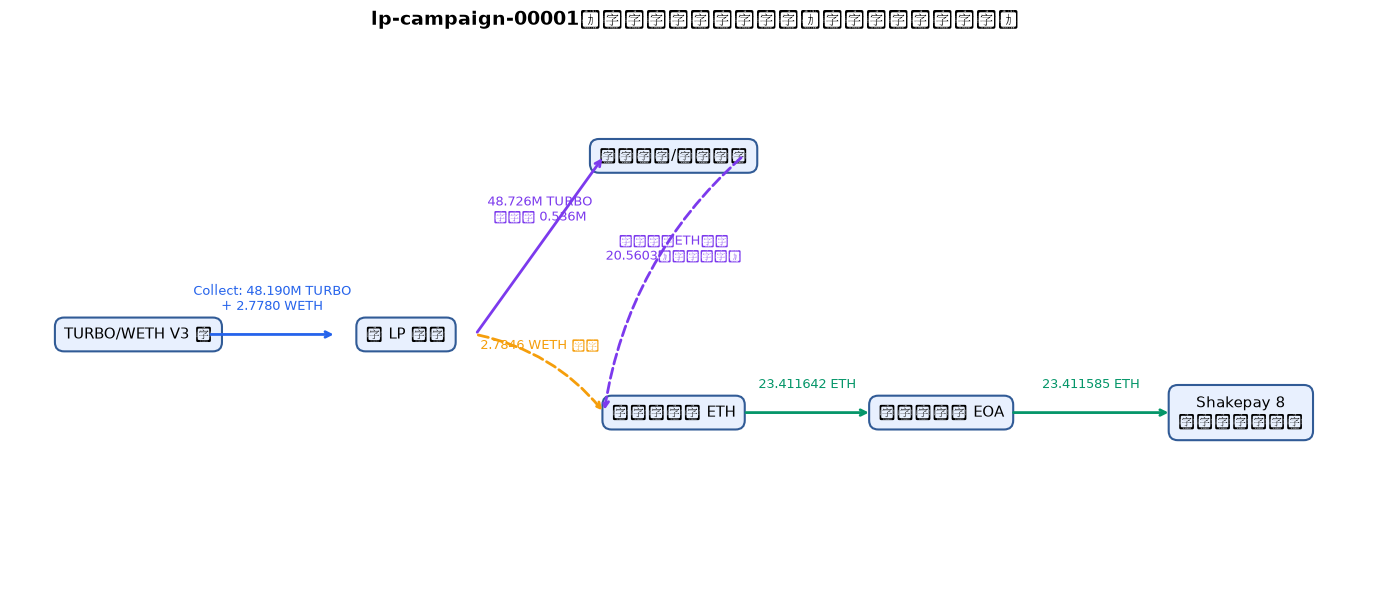

In [7]:
fig, ax = plt.subplots(figsize=(14, 6))
ax.axis('off')
nodes = {
    'pool': (0.7, 3.0, 'TURBO/WETH V3 池'),
    'wallet': (3.2, 3.0, '原 LP 钱包'),
    'routes': (5.7, 4.6, '聚合交易/执行路径'),
    'eth': (5.7, 2.3, '原钱包中的 ETH'),
    'mid': (8.2, 2.3, '无标签中转 EOA'),
    'shakepay': (11.0, 2.3, 'Shakepay 8\n第三方公开标签'),
}
for _, (x, y, label) in nodes.items():
    ax.text(x, y, label, ha='center', va='center', fontsize=11,
            bbox=dict(boxstyle='round,pad=.6', fc='#e8f0fe', ec='#315b96', lw=1.5))

def arrow(a, b, text, color='#334155', style='-', rad=0):
    x1,y1,_=nodes[a]; x2,y2,_=nodes[b]
    ax.annotate('', xy=(x2-.65,y2), xytext=(x1+.65,y1),
                arrowprops=dict(arrowstyle='->', lw=2, color=color, linestyle=style,
                                connectionstyle=f'arc3,rad={rad}'))
    ax.text((x1+x2)/2, (y1+y2)/2 + .22, text, ha='center', fontsize=9, color=color)

arrow('pool','wallet','Collect: 48.190M TURBO\n+ 2.7780 WETH','#2563eb')
arrow('wallet','routes','48.726M TURBO\n含原有 0.536M','#7c3aed')
arrow('routes','eth','同期其他ETH流入\n20.5603（余额残差）', '#7c3aed', '--', .18)
arrow('wallet','eth','2.7846 WETH 解包', '#f59e0b', '--', -.18)
arrow('eth','mid','23.411642 ETH','#059669')
arrow('mid','shakepay','23.411585 ETH','#059669')
ax.set_xlim(-.5,12.3); ax.set_ylim(.8,5.7)
ax.set_title('lp-campaign-00001：链上可观察资金路径（不是受益所有权图）', fontsize=14, weight='bold')
plt.tight_layout()
plt.show()


## Part 7：按分钟排列完整动作

这张时间线用于回答“资金是否在撤出流动性后长期闲置，还是被快速处置并转移”。


/var/folders/56/4nq1_gvn5c17bwx0djrtyj1m0000gn/T/ipykernel_41337/349132944.py:24: UserWarning: Glyph 36317 (\N{CJK UNIFIED IDEOGRAPH-8DDD}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/56/4nq1_gvn5c17bwx0djrtyj1m0000gn/T/ipykernel_41337/349132944.py:24: UserWarning: Glyph 30340 (\N{CJK UNIFIED IDEOGRAPH-7684}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/56/4nq1_gvn5c17bwx0djrtyj1m0000gn/T/ipykernel_41337/349132944.py:24: UserWarning: Glyph 20998 (\N{CJK UNIFIED IDEOGRAPH-5206}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/56/4nq1_gvn5c17bwx0djrtyj1m0000gn/T/ipykernel_41337/349132944.py:24: UserWarning: Glyph 38047 (\N{CJK UNIFIED IDEOGRAPH-949F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/56/4nq1_gvn5c17bwx0djrtyj1m0000gn/T/ipykernel_41337/349132944.py:24: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/56/4nq1_gvn5

/opt/anaconda3/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 21518 (\N{CJK UNIFIED IDEOGRAPH-540E}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 21069 (\N{CJK UNIFIED IDEOGRAPH-524D}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 20998 (\N{CJK UNIFIED IDEOGRAPH-5206}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 38047 (\N{CJK UNIFIED IDEOGRAPH-949F}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 25764 (\N{CJK UNIFIED IDEOGRAPH-64A4}) missing from font(s) DejaV

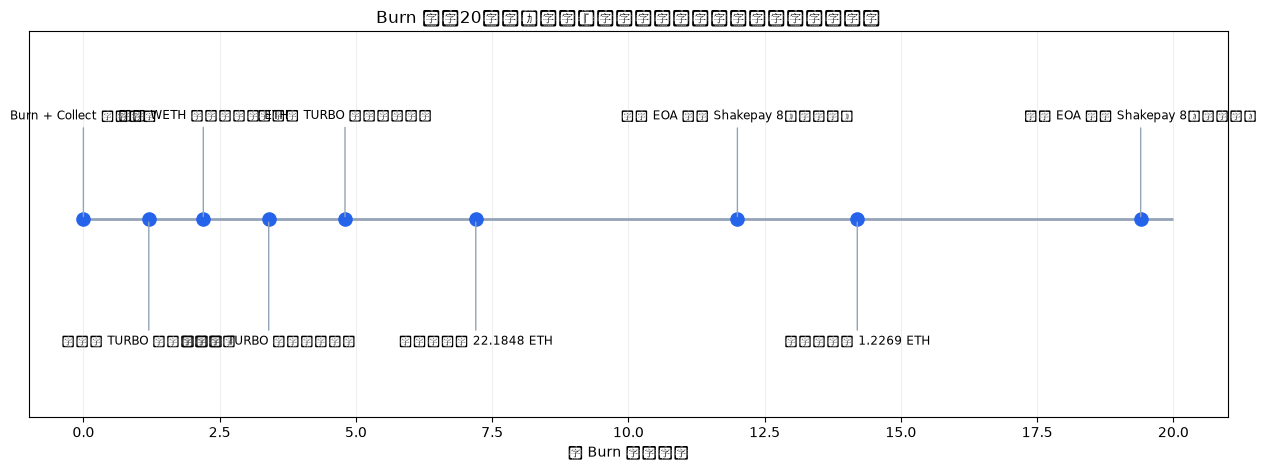

In [8]:
events = [
    (0.0, 'Burn + Collect 到原钱包'),
    (1.2, '第一批 TURBO 进入交易路径'),
    (2.2, '钱包 WETH 全部解包为 ETH'),
    (3.4, '第二批 TURBO 进入交易路径'),
    (4.8, '第三批 TURBO 进入执行合约'),
    (7.2, '原钱包转出 22.1848 ETH'),
    (12.0, '中转 EOA 转入 Shakepay 8（第一笔）'),
    (14.2, '原钱包转出 1.2269 ETH'),
    (19.4, '中转 EOA 转入 Shakepay 8（第二笔）'),
]
fig, ax = plt.subplots(figsize=(13, 4.8))
x=[e[0] for e in events]
ax.scatter(x, [0]*len(x), s=90, color='#2563eb', zorder=3)
ax.hlines(0, 0, 20, color='#94a3b8', lw=2)
for i,(minute,label) in enumerate(events):
    y=.55 if i%2==0 else -.65
    ax.annotate(label, (minute,0), xytext=(minute,y), ha='center', va='center', fontsize=8.5,
                arrowprops=dict(arrowstyle='-', color='#94a3b8'))
ax.set_xlim(-1,21); ax.set_ylim(-1.05,1.0); ax.set_yticks([])
ax.set_xlabel('距 Burn 的分钟数')
ax.set_title('Burn 后前20分钟：撤资、资产处置与公开标签地址到达路径')
ax.grid(axis='x', alpha=.2)
plt.tight_layout()
plt.show()


## Part 8：本案例最终结论

> 这个 campaign 的“30天没有重新 Mint”不是资金闲置。Collect后的TURBO/WETH余额在1小时内清零；钱包在连续处置资产后，将23.4116 ETH经一个中转EOA转入Blockscan当时标记为Shakepay 8的地址。余额对账确认其中2.7846 ETH来自WETH解包，另有20.5603 ETH来自同期其他原生ETH流入，但现有RPC证据不足以把这部分逐笔归因给某一笔TURBO交易。

因此，对这个**具体案例**，更合适的描述是：

- 它符合“退出已扫描 TURBO/WETH LP”的链上特征；
- 资金没有停留在原钱包，也没有回到已扫描的同交易对 V3 池；
- 钱包在同期收到额外原生ETH后快速转出，并到达一个带第三方公开服务标签的地址；
- 不能进一步声称已经法币提现，也不能仅凭地址路径认定自然人身份。

这是一条单案例的余额与转账证据链，不代表其他LP大户都会采取同样行为，也不是对最终资金来源的完整Trace。


In [9]:
display(labels[['address','label','category','label_evidence','source_url','beneficial_owner_inferred']])


,address,label,category,label_evidence,source_url,beneficial_owner_inferred
0,0x111111125421cA6dc452d289314280a0f8842A65,1inch Aggregation Router,swap_router,public protocol contract,https://etherscan.io/address/0x111111125421ca6...,False
1,0x34756D8400f2426851dc46D6ab38F0Df004CE1E7,Unlabeled EOA,eoa,onchain code check,NaN,False
2,0x5ffd352BE09660Ee4221713A08012EC33F1Ba139,Unlabeled intermediary EOA,eoa,onchain code check,https://etherscan.io/address/0x5ffd352be09660e...,False
3,0x6131B5fae19EA4f9D964eAc0408E4408b66337b5,KyberSwap MetaAggregationRouterV2,swap_router,official KyberSwap deployment docs,https://docs.kyberswap.com/kyberswap-solutions...,False
4,0x7DBB4bdCfE614398D1a68ecc219F15280d0959E0,"Shakepay 8 (public label, not independently ve...",externally_labeled_service,Blockscan third-party public label; official/c...,https://blockscan.com/Address/0x7dbb4bdcfe6143...,False
5,0x7baecE5d47f1BC5E1953FBE0E9931D54DAB6D810,TURBO/WETH V3 1% pool,liquidity_pool,Factory-verified project ledger,NaN,False
6,0x8F10B468b06c6FD214B65F87778827F7D113f996,KyberSwap transaction execution contract,execution_contract,same-transaction call/transfer evidence,NaN,False
7,0xA35923162C49cF95e6BF26623385eb431ad920D3,Unlabeled contract,contract,onchain code check,NaN,False
8,0xAC4c6e212A361c968F1725b4d055b47E63F80b75,Unlabeled contract,contract,onchain code check,NaN,False
9,0xC02aaA39b223FE8D0A0e5C4F27eAD9083C756Cc2,Unlabeled contract,contract,onchain code check,NaN,False


## 附录：为什么不分析另一个低恢复 campaign？

另一个 campaign 到数据终点只观察了约8天，不满足30天观察要求。它只能标记为“观察不足”，不能和主案例一起写成长期撤离。


In [10]:
display(censored)

assert len(case) == 1
assert bool(case.iloc[0].persistent_non_return_scanned_pair_30d)
assert collect.iloc[0].collect_recipient.lower() == case.iloc[0].wallet_address.lower()
assert balances.loc[balances.checkpoint == '1h', 'turbo_balance'].iloc[0] == 0
assert balances.loc[balances.checkpoint == '1h', 'weth_balance'].iloc[0] == 0
assert manifest['intermediary_eth_sent_to_public_shakepay_label'] > 23.4
print('QA passed: one uncensored persistent case, exact Collect recipient, 1h balance clearance, and two-hop ETH path verified.')


,campaign_id,wallet_address,burn_block_number,burn_transaction_hash,followup_days,net_recovery_ratio_30d,is_censored_30d,net_status_30d
0,lp-campaign-00159,0xC216BfA5dA000965E820845c32e6FD88DB275743,25886731,0x323346c50adcb19067f2396b51e2aa11da1a4c380864...,8.083472,-0.001808,True,censored


QA passed: one uncensored persistent case, exact Collect recipient, 1h balance clearance, and two-hop ETH path verified.
